In [1]:
import pandas as pd

# 加载 Excel 文件
xls = pd.ExcelFile("../data/processed/store_sales_split.xlsx")

# 读取第二个 sheet（通常是第一家门店）
df_store_1 = pd.read_excel(xls, sheet_name=xls.sheet_names[1])

# 按日期统计总商品数
total_per_day = df_store_1.groupby('Date').size().reset_index(name='Total_Items')

# 按日期统计促销商品数
promo_per_day = df_store_1[df_store_1['Promotion'] == 1].groupby('Date').size().reset_index(name='Promo_Items')

# 合并两个统计结果
stats = pd.merge(total_per_day, promo_per_day, on='Date', how='left')
stats['Promo_Items'] = stats['Promo_Items'].fillna(0).astype(int)

# 计算占比
stats['Promo_Ratio'] = (stats['Promo_Items'] / stats['Total_Items']).round(4)

print(stats)

          Date  Total_Items  Promo_Items  Promo_Ratio
0   2022-01-01           20            3         0.15
1   2022-01-02           20            4         0.20
2   2022-01-03           20            7         0.35
3   2022-01-04           20            9         0.45
4   2022-01-05           20           14         0.70
..         ...          ...          ...          ...
755 2024-01-26           20            6         0.30
756 2024-01-27           20           11         0.55
757 2024-01-28           20            7         0.35
758 2024-01-29           20            0         0.00
759 2024-01-30           20            0         0.00

[760 rows x 4 columns]


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_promo_ratio(data, start_date, end_date):
    """
    绘制指定时间范围内的促销覆盖率曲线图

    参数：
    - data: 包含 Date 和 Promo_Ratio 列的原始 DataFrame
    - start_date: 起始日期（字符串格式，如 '2022-01-01'）
    - end_date: 结束日期（字符串格式，如 '2022-06-30'）
    """
    # 确保日期列为 datetime 类型
    data['Date'] = pd.to_datetime(data['Date'])

    # 筛选指定时间范围的数据
    mask = (data['Date'] >= start_date) & (data['Date'] <= end_date)
    filtered_data = data.loc[mask]

    # 设置图像大小
    plt.figure(figsize=(14, 6))

    # 绘制促销覆盖率曲线
    plt.plot(filtered_data['Date'], filtered_data['Promo_Ratio'],
             color='purple', linewidth=1.5, label='Promo Ratio')

    # 添加图表标题和坐标轴标签
    plt.title(f'Promotion Coverage Ratio ({start_date} to {end_date})', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Promotion Ratio', fontsize=12)

    # 设置 x 轴刻度旋转角度
    plt.xticks(rotation=45)

    # 添加网格线和图例
    plt.grid(True)
    plt.legend()

    # 自动调整布局
    plt.tight_layout()

    # 显示图表
    plt.show()

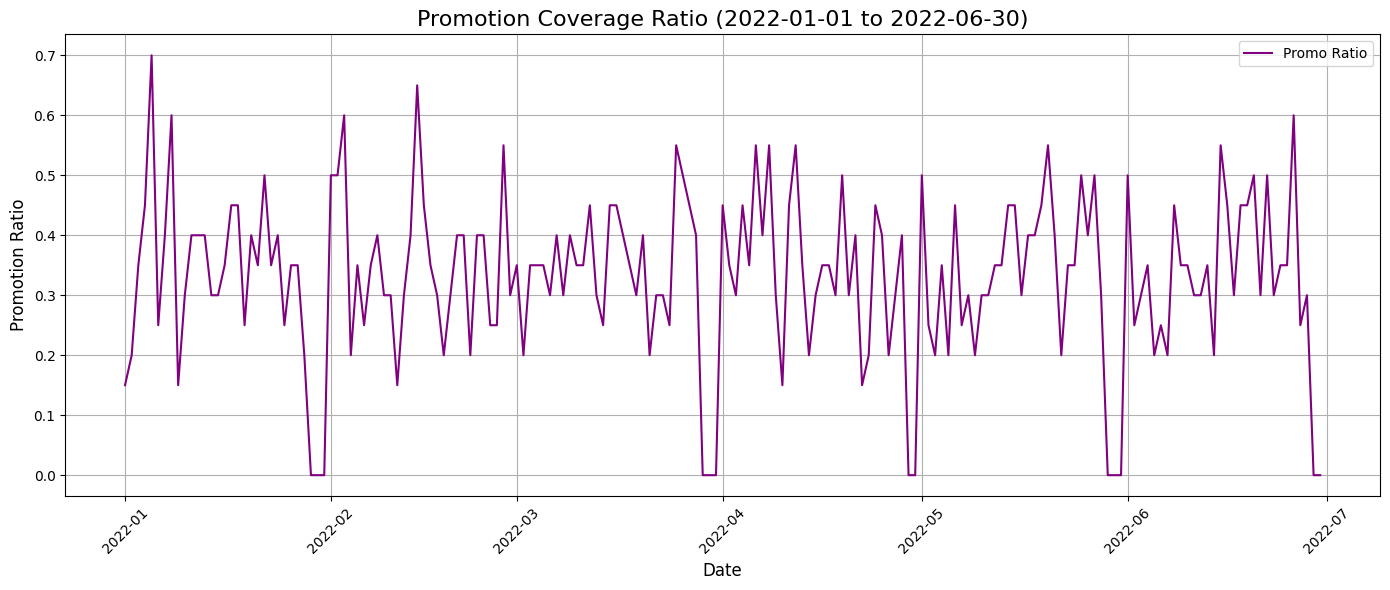

In [3]:
plot_promo_ratio(stats, '2022-01-01', '2022-06-30')

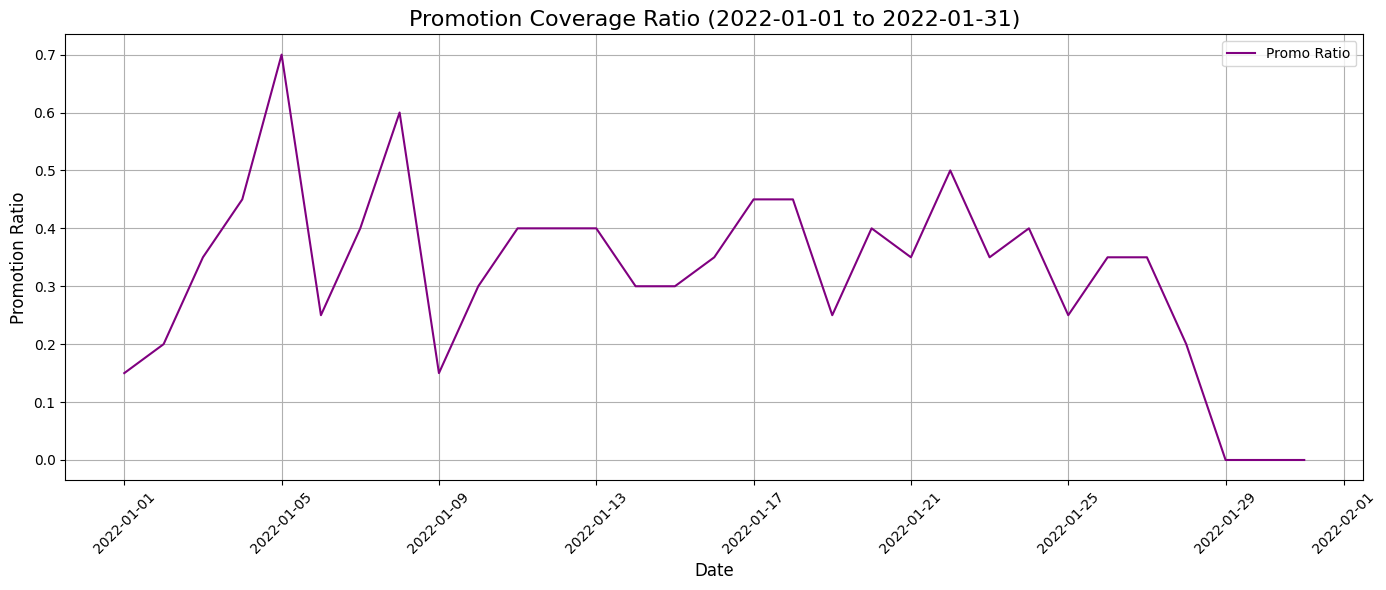

In [4]:
plot_promo_ratio(stats, '2022-01-01', '2022-01-31')